In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from pyimzml.ImzMLParser import ImzMLParser
from scipy.ndimage import median_filter
from skimage.morphology import remove_small_objects
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras import layers, models
import glob
from tqdm import tqdm
import h5py
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import json
import time


warnings.filterwarnings(
    "ignore",
    message=".*Accession MS:.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*Accession IMS:.*"
)

%matplotlib inline

# Change path here to read and write data

In [18]:
bin_limits = (500.01094539, 1001.515)

interval = 0.012

n_clusters = 3

# Maximum number of valid pixels kept per cell type during preprocessing.
# Set to None to keep all of them.
MAX_PIXELS_PER_TYPE = 1000

# Change here:
INPUT_PATH = r"C:\Users\aitor\Desktop\Neural Lipotypes\cell_types_spectrum"

OUTPUT_PATH = Path(r"C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\clean_cells")

In [3]:
class CellReading():

    def __init__(self, path=INPUT_PATH):

        self.path = path

        self.cell_net = {}  # dict: cell_type -> list of (file_name, ImzMLParser, max_x, max_y)

        # Reading all the cells
        for dir in os.listdir(path):
            inp = os.path.join(self.path, dir, "raw")

            for doc in os.listdir(inp):
                if doc.endswith(".imzML"):
                    input_path = os.path.join(inp, doc)

                    imzML, max_x, max_y = self._load_BTS(input_path)

                    self.cell_net.setdefault(dir, []).append((doc, imzML, max_x, max_y))

    def _load_BTS(self, input_path):

        parser = ImzMLParser(input_path)
        coords = parser.coordinates

        max_x = max(c[0] for c in coords)
        max_y = max(c[1] for c in coords)

        return parser, max_x, max_y

In [4]:
class CellPreparator(CellReading):  # Common bin_limit = (500.01094539, 1001.515)

    def __init__(self, bins_limits=bin_limits, step=interval):

        # NOTE: this still re-parses every .imzML file on disk (CellReading.__init__).
        # Only instantiate CellPreparator ONCE per session and reuse it.
        super().__init__()

        self.cells = self.cell_net
        self.bins_limits = bins_limits
        self.step = step

    def _nan_filter(self, vector):

        mask = ~np.isnan(vector)

        return np.vstack(vector)[mask]

    def _thresholded_BTS(self, AvS, threshold=50000):
        """
        This functions returns thresholded AvS and bmz
        """

        T_AvS = []

        for spectrum in AvS:
            spec = spectrum.copy()  # evitar modificar el original
            spec[spec <= threshold] = 0.
            T_AvS.append(spec)

        return np.vstack(T_AvS)

    def spec_normalization(self, spectrum):

        norm_intA_i = spectrum * 1.0e8 / (np.nansum(spectrum) + 1e-8)

        return norm_intA_i

    def _clustering(self, mz, intensity, bins_limits=None):
        """
        Bins a raw (mz, intensity) spectrum into a common m/z axis shared by
        all pixels/files, so every spectrum ends up with the same length and
        the same bin meaning. Must be done per pixel.
        """

        if bins_limits is None:
            bins_limits = self.bins_limits

        start, stop = bins_limits

        bin_edges = np.arange(
            start,
            stop + self.step,
            self.step
        )

        mz_bins = (bin_edges[:-1] + bin_edges[1:]) / 2

        intensity = self.spec_normalization(intensity)

        # Thresholding intensities
        intensity = self._thresholded_BTS(intensity.reshape(1, -1))
        intensity = intensity.reshape(-1)

        # Assign each m/z value to its corresponding bin
        indices = np.digitize(x=mz, bins=bin_edges) - 1

        # Filter out indices that are out of range
        valid = (indices >= 0) & (indices < len(bin_edges) - 1)
        indices = indices[valid]
        intensity_values = intensity[valid]

        # Sum intensities per bin using np.bincount
        intensity_binned = np.bincount(indices, weights=intensity_values, minlength=len(mz_bins))

        counts_per_bin = np.bincount(indices, minlength=len(mz_bins))

        # Set NaN only if a bin received no m/z values at all
        intensity_binned[counts_per_bin == 0] = np.nan

        return mz_bins, intensity_binned

In [5]:
class KMeansClustering():

    def __init__(self, kmatrix, n_clusters=n_clusters):

        self.matrix = np.nanmean(kmatrix, axis=2)
        self.max_x, self.max_y = self.matrix.shape
        self.n_clusters = n_clusters

    def KMeansCluster(self):

        model = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=0)

        data = self.matrix.reshape(-1)

        # Masking nan values (positions never measured / fully filtered out)
        mask = ~np.isnan(data)
        labels = np.full(data.shape[0], -1, dtype=int)

        if mask.sum() == 0:
            cluster_map = labels.reshape(self.max_x, self.max_y)
            return cluster_map, -1

        valid_data = data[mask].reshape(-1, 1)
        labels[mask] = model.fit_predict(valid_data)
        cluster_map = labels.reshape(self.max_x, self.max_y)

        # --- background = highest-intensity cluster ---
        centers = model.cluster_centers_.flatten()
        background_cluster = int(np.argmax(centers))

        # --- tissue = most populous cluster among the remaining ones ---
        counts = np.bincount(labels[mask], minlength=self.n_clusters)
        counts[background_cluster] = -1  # exclude background from the vote
        tissue_cluster = int(np.argmax(counts))

        # Spatial clean-up
        valid_mask = cluster_map != -1
        filtered = median_filter(cluster_map, size=3)
        cluster_map[valid_mask] = filtered[valid_mask]

        # Removing small isolated objects from the tissue mask
        tissue_mask = (cluster_map == tissue_cluster)
        tissue_mask = remove_small_objects(tissue_mask, max_size=128)

        cluster_map[~tissue_mask] = -1

        return cluster_map, tissue_cluster

In [6]:
class ModelPreparator(CellPreparator):
    """
    Reads all cell spectra, normalizes them, bins them onto a common m/z
    axis and filters out background pixels via KMeans.

    For each cell type it creates, inside OUTPUT_PATH:
        OUTPUT_PATH/<cell_type>/labels.csv   -> metadata (file, x, y, row_index)
        OUTPUT_PATH/<cell_type>/spectra.h5   -> dataset "spectra" (N_pixels, N_bins)
                                                  dataset "mz"      (N_bins,)

    Adding a new cell type later only requires dropping a new folder under
    INPUT_PATH and re-running dictionary_prep(); nothing else needs to change.

    KMeans does not always separate tissue from background cleanly for every
    imzML file. Rather than hardcoding per-file fixes inside this class
    (as filename-based pixel selection used to do), bad files are handled
    via an explicit `file_overrides` dict passed to dictionary_prep():

        file_overrides = {
            "SomeFile_pos.imzML": "skip",
            "OtherFile_pos.imzML": {"x_min": 1, "x_max": 50, "y_min": 126, "y_max": 200},
        }

    "skip"  -> the file is discarded entirely.
    a dict  -> KMeans is bypassed for that file and the given rectangular
               region (inclusive, 1-indexed, same convention as x/y in the
               CSV) is used as the tissue mask instead.
    """

    def __init__(self, OUTPUT_PATH=OUTPUT_PATH):

        self.data = CellPreparator()

        self.cell_dictionary = self.data.cells
        self.bins_limits = self.data.bins_limits
        self.mz = None
        self.OUTPUT_PATH = Path(OUTPUT_PATH)

        self.Cluster_on = True

    def _build_kmatrix(self, imzML, max_x, max_y):

        coords = imzML.coordinates

        mz0, _ = imzML.getspectrum(0)
        binned_mz, _ = self.data._clustering(mz0, np.zeros_like(mz0))
        n_bins = len(binned_mz)

        kmatrix_int = np.full((max_x, max_y, 1), np.nan)
        kmatrix_spec = np.full((max_x, max_y, n_bins), np.nan)

        for i, (x, y, z) in enumerate(coords):
            mz, intensity = imzML.getspectrum(i)
            binned_mz, binned_intensity = self.data._clustering(mz, intensity)

            kmatrix_int[x - 1, y - 1, 0] = np.nanmean(binned_intensity)
            kmatrix_spec[x - 1, y - 1, :] = binned_intensity

        return kmatrix_spec, kmatrix_int, binned_mz

    def compute_cell_net(self, imzML, max_x, max_y, manual_bounds=None):

        kmatrix_spec, kmatrix_int, binned_mz = self._build_kmatrix(imzML, max_x, max_y)

        if manual_bounds is not None:
            mask2d = np.zeros((max_x, max_y), dtype=bool)
            x0, x1 = manual_bounds["x_min"] - 1, manual_bounds["x_max"]
            y0, y1 = manual_bounds["y_min"] - 1, manual_bounds["y_max"]
            mask2d[x0:x1, y0:y1] = True

        elif self.Cluster_on:
            cluster_map, tissue_cluster = KMeansClustering(kmatrix_int).KMeansCluster()
            mask2d = (cluster_map == tissue_cluster)

        else:
            mask2d = ~np.isnan(kmatrix_int[:, :, 0])

        mask = np.repeat(mask2d[:, :, None], kmatrix_spec.shape[2], axis=2)
        kmatrix_spec = np.where(mask, kmatrix_spec, np.nan)

        return kmatrix_spec, binned_mz

    def qc_cluster_preview(self, save_dir=None): # Visualizar célula y máscara
        """
        For every imzML file, plots side by side:
          - the mean-intensity (TIC) image
          - the tissue mask chosen by KMeans

        Use this to spot files where KMeans fails before deciding the
        `file_overrides` dict for dictionary_prep().
        """
        save_dir = Path(save_dir) if save_dir else None
        if save_dir is not None:
            save_dir.mkdir(parents=True, exist_ok=True)

        for key in self.cell_dictionary.keys():
            for doc, imzML, max_x, max_y in self.cell_dictionary[key]:

                _, kmatrix_int, _ = self._build_kmatrix(imzML, max_x, max_y)
                mean_map = kmatrix_int[:, :, 0]

                cluster_map, tissue_cluster = KMeansClustering(kmatrix_int).KMeansCluster()
                tissue_mask = (cluster_map == tissue_cluster)

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(mean_map, cmap="viridis")
                axes[0].set_title("Mean intensity")
                axes[1].imshow(tissue_mask, cmap="gray")
                axes[1].set_title("KMeans tissue mask")
                fig.suptitle(f"{key} - {doc}")
                plt.tight_layout()

                if save_dir is not None:
                    plt.savefig(save_dir / doc.replace(".imzML", "_qc.png"))
                    plt.close(fig)
                else:
                    plt.show()

    def dictionary_prep(self, max_pixels_per_type=MAX_PIXELS_PER_TYPE, seed=42,
                         file_overrides=None):
        """
        Processes every imzML file, grouped by cell type, and writes one
        labels.csv + spectra.h5 pair per cell type under self.OUTPUT_PATH.

        file_overrides: see class docstring. Keyed by the imzML file name
        (the same string stored in the "file_name" column / `doc`).

        If max_pixels_per_type is set, each cell type is randomly
        subsampled (after background filtering) down to that many pixels.
        """

        rng = np.random.default_rng(seed)
        file_overrides = file_overrides or {}
        self.OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

        for key in self.cell_dictionary.keys():

            type_dir = self.OUTPUT_PATH / key
            type_dir.mkdir(parents=True, exist_ok=True)

            h5_path = type_dir / "spectra.h5"
            csv_path = type_dir / "labels.csv"

            all_rows = []
            all_spectra = []
            binned_mz = None

            for doc, imzML, max_x, max_y in tqdm(self.cell_dictionary[key], desc=key):

                override = file_overrides.get(doc)

                if override == "skip":
                    print(f"[SKIP] {doc} (manual override)")
                    continue

                manual_bounds = override if isinstance(override, dict) else None

                kmatrix_spec, binned_mz = self.compute_cell_net(
                    imzML, max_x, max_y, manual_bounds=manual_bounds
                )

                coords = np.array([(i + 1, j + 1) for i in range(max_x) for j in range(max_y)])
                X = kmatrix_spec.reshape(-1, kmatrix_spec.shape[-1])

                valid = ~np.all(np.isnan(X), axis=1)

                coords = coords[valid]
                X = X[valid]

                for c, spec in zip(coords, X):
                    all_rows.append({"cell_type": key, "file_name": doc, "x": int(c[0]), "y": int(c[1])})
                    all_spectra.append(spec)

            if len(all_spectra) == 0:
                print(f"[WARN] No valid (tissue) pixels found for '{key}', skipping.")
                continue

            df_type = pd.DataFrame(all_rows)
            X_type = np.asarray(all_spectra, dtype=np.float32)

            if max_pixels_per_type is not None and len(df_type) > max_pixels_per_type:
                sel = rng.choice(len(df_type), size=max_pixels_per_type, replace=False)
                sel = np.sort(sel)
                df_type = df_type.iloc[sel].reset_index(drop=True)
                X_type = X_type[sel]
            else:
                df_type = df_type.reset_index(drop=True)

            df_type["row_index"] = np.arange(len(df_type))

            df_type.to_csv(csv_path, sep=";", index=False)

            max_attempts = 5
            for attempt in range(1, max_attempts + 1):
                try:
                    with h5py.File(h5_path, "w") as f:
                        f.create_dataset(
                            "spectra",
                            data=X_type,
                            dtype=np.float32,
                            compression="gzip",
                            compression_opts=4
                        )
                        f.create_dataset("mz", data=np.asarray(binned_mz, dtype=np.float32))
                    break
                except OSError as e:
                    if attempt == max_attempts:
                        raise OSError(
                            f"No se pudo escribir '{h5_path}' tras {max_attempts} intentos. "
                        ) from e
                    print(f"[WARN] No se pudo abrir {h5_path} (intento {attempt}/{max_attempts}): {e}. Reintentando...")
                    time.sleep(1.5)

            print(f"{key}: saved {len(df_type)} pixels -> {h5_path}")

        if binned_mz is not None:
            self.mz = binned_mz

### Paso de QC antes de procesar todo el dataset

Este paso sirve para decidir qué píxeles usar en el entrenamiento

In [7]:
cell = ModelPreparator()

In [8]:
QC_DIR = OUTPUT_PATH / "_qc_previews"
cell.qc_cluster_preview(save_dir=QC_DIR)
print(f"Revisa las imágenes en: {QC_DIR}")

Revisa las imágenes en: C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\_qc_previews


In [9]:
file_overrides = {
    # "Plexo_1_2_3_4_5_6_7_8_9_10_pos_20160218_IMS97_1A_pos.imzML": {
    #     "x_min": 1, "x_max": 50, "y_min": 126, "y_max": 200
    # },
    # "AlgunFicheroProblematico.imzML": "skip",
}

In [10]:
KEEP_FILES = {
    "Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML",
    "Microglia_13_14_15_16__17_pos_20160218_IMS96_2D_pos.imzML",
    "Neuron_13_14_15_pos_20150604_rataneu_pos.imzML",
    "Oligo_11_12_13_14_pos_20151211_IMS95_2_pos.imzML",
    "Plexo_11_12_13_14_pos_20160218_IMS97_1B_pos.imzML",
    "Plexo_1_2_3_4_5_6_7_8_9_10_pos_20160218_IMS97_1A_pos.imzML",
}

PLEXO_1A_BOUNDS = {"x_min": 1, "x_max": 20, "y_min": 126, "y_max": 210}

file_overrides = {}

for key in cell.cell_dictionary:
    for doc, imzML, max_x, max_y in cell.cell_dictionary[key]:
        if doc not in KEEP_FILES:
            file_overrides[doc] = "skip"

file_overrides["Plexo_1_2_3_4_5_6_7_8_9_10_pos_20160218_IMS97_1A_pos.imzML"] = PLEXO_1A_BOUNDS

print(f"{len(file_overrides)} ficheros marcados como skip/manual_bounds")
print(f"Se procesarán normalmente: "
      f"{KEEP_FILES - {'Plexo_1_2_3_4_5_6_7_8_9_10_pos_20160218_IMS97_1A_pos.imzML'}}")

29 ficheros marcados como skip/manual_bounds
Se procesarán normalmente: {'Oligo_11_12_13_14_pos_20151211_IMS95_2_pos.imzML', 'Plexo_11_12_13_14_pos_20160218_IMS97_1B_pos.imzML', 'Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML', 'Microglia_13_14_15_16__17_pos_20160218_IMS96_2D_pos.imzML', 'Neuron_13_14_15_pos_20150604_rataneu_pos.imzML'}


Y ahora a guardar datos (un .csv + .h5 por cada tipo celular, dentro de OUTPUT_PATH)

In [11]:
cell = ModelPreparator()

In [12]:
cell.dictionary_prep(max_pixels_per_type=MAX_PIXELS_PER_TYPE, file_overrides=file_overrides)

Astro_Positivo:   0%|          | 0/18 [00:00<?, ?it/s]

[SKIP] Astro_12_13_14_pos_20150505_tejidorata2_pos.imzML (manual override)


Astro_Positivo: 100%|██████████| 18/18 [00:01<00:00, 10.77it/s]


[SKIP] Astro_17_18_pos_20150506_cultivocorte_2_pos.imzML (manual override)
[SKIP] Astro_19_20_pos_20150506_cultivocorte_3_pos.imzML (manual override)
[SKIP] Astro_1_2_pos_20150504_tejidorata1_pos.imzML (manual override)
[SKIP] Astro_21_22_pos_20150506_cultivocorte_4_pos.imzML (manual override)
[SKIP] Astro_23_24_25_pos_20150506_cultivogota_1_pos.imzML (manual override)
[SKIP] Astro_26_27_28_pos_20150506_cultivogota_2_pos.imzML (manual override)
[SKIP] Astro_29_pos_20150508_tejidorata_cultivo_1_pos.imzML (manual override)
[SKIP] Astro_30_pos_20150508_tejidorata_cultivo_2_pos.imzML (manual override)
[SKIP] Astro_31_pos_20150518_tejidorata_cultivo_1_pos.imzML (manual override)
[SKIP] Astro_32_pos_20150518_tejidorata_cultivo_2_pos.imzML (manual override)
[SKIP] Astro_33_34_35_pos_20150604_rataastro_pos.imzML (manual override)
[SKIP] Astro_36_37_38__39_40_pos_20150615_rataastro_pos.imzML (manual override)
[SKIP] Astro_3_4_pos_20150504_tejidorata2_pos.imzML (manual override)
[SKIP] Astro_5_6

Microglia_Positivo:   0%|          | 0/6 [00:00<?, ?it/s]

...

[SKIP] Neuron_16_pos_20150615_rataneu_pos.imzML (manual override)
[SKIP] Neuron_17_18_pos_20150615_rataneu2_pos.imzML (manual override)
[SKIP] Neuron_1_2_3_4_5_6_7_8_9_pos_20150602_rata1cul_pos.imzML (manual override)
Neuron_Positivo: saved 1000 pixels -> C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\Neuron_Positivo\spectra.h5


Oligo_Positivo: 100%|██████████| 3/3 [00:02<00:00,  1.12it/s]


[SKIP] Oligo_1_2_3_4_5_pos_20151211_IMS95_1A_pos.imzML (manual override)
[SKIP] Oligo_6_7_8_9_10_pos_20151211_IMS95_1B_pos.imzML (manual override)
Oligo_Positivo: saved 1000 pixels -> C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\Oligo_Positivo\spectra.h5


Plexo_Positivo: 100%|██████████| 2/2 [00:04<00:00,  2.45s/it]


Plexo_Positivo: saved 1000 pixels -> C:\Users\aitor\Desktop\GitHub - Lipotyper\TFG_Aitor\TFG_Aitor\neural_model\Plexo_Positivo\spectra.h5


### Carga genérica del dataset

In [13]:
def load_dataset(output_path, cell_types=None):

    output_path = Path(output_path)

    if cell_types is None:
        cell_types = sorted(
            d.name for d in output_path.iterdir()
            if d.is_dir() and (d / "labels.csv").exists() and (d / "spectra.h5").exists()
        )

    dfs = []
    h5_files = {}

    for ct in cell_types:
        csv_path = output_path / ct / "labels.csv"
        h5_path = output_path / ct / "spectra.h5"

        if not csv_path.exists() or not h5_path.exists():
            print(f"[WARN] Missing files for '{ct}', skipping.")
            continue

        df_ct = pd.read_csv(csv_path, sep=";")
        dfs.append(df_ct)
        h5_files[ct] = h5py.File(h5_path, "r")

    if not dfs:
        raise FileNotFoundError(f"No valid cell type data found under {output_path}")

    df = pd.concat(dfs, ignore_index=True)
    return df, h5_files


def close_dataset(h5_files):
    for f in h5_files.values():
        f.close()


def get_spectra(df, h5_files, mask=None, fill_nan=0.0):

    if mask is not None:
        df = df[mask]

    df = df.reset_index(drop=True)

    n_bins = next(iter(h5_files.values()))["spectra"].shape[1]
    X = np.full((len(df), n_bins), np.nan, dtype=np.float32)

    for ct, group in df.groupby("cell_type"):
        idx = group["row_index"].to_numpy()
        order = np.argsort(idx)
        rows = h5_files[ct]["spectra"][np.sort(idx)]
        X[group.index.to_numpy()[order]] = rows

    if fill_nan is not None:
        X = np.nan_to_num(X, nan=fill_nan)

    return X

In [14]:
df, h5_files = load_dataset(OUTPUT_PATH)

print(df["cell_type"].value_counts())
print(df.head())

cell_type
Astro_Positivo        1000
Microglia_Positivo    1000
Neuron_Positivo       1000
Oligo_Positivo        1000
Plexo_Positivo        1000
Name: count, dtype: int64
        cell_type                                          file_name  x   y  \
0  Astro_Positivo  Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML  1   7   
1  Astro_Positivo  Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML  1   8   
2  Astro_Positivo  Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML  1   9   
3  Astro_Positivo  Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML  1  10   
4  Astro_Positivo  Astro_15_16_pos_20150506_cultivocorte_1_pos.imzML  1  11   

   row_index  
0          0  
1          1  
2          2  
3          3  
4          4  


Es hora de crear la clase y el modelo que haga predicciones

In [15]:
class CellTypeModel():

    def __init__(self, output_path=OUTPUT_PATH, model_output_path=None,
                 n_components=100, epochs=50, batch_size=32):

        self.output_path = Path(output_path)
        self.model_output_path = Path(model_output_path) if model_output_path else self.output_path / "neural_network"
        self.model_output_path.mkdir(parents=True, exist_ok=True)

        self.n_components = n_components
        self.epochs = epochs
        self.batch_size = batch_size

        self.df, self.h5_files = load_dataset(self.output_path)

        self.classes_ = sorted(self.df["cell_type"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes_)}

        with open(self.model_output_path / "class_to_idx.json", "w") as f:
            json.dump(self.class_to_idx, f, indent=2)

        X_train, X_val, y_train, y_val = self._split()

        X_train_pca, X_val_pca = self._compact(X_train, X_val)

        self.model = self._model_create(X_train_pca, y_train, X_val_pca, y_val)

        close_dataset(self.h5_files)

    def _split(self):

        counts = self.df["cell_type"].value_counts()
        min_count = int(counts.min())

        # Se toma como número de pixeles el tipo celular con menor cantidad
        df_balanced = (
            pd.concat([
                g.sample(min_count, random_state=42)
                for _, g in self.df.groupby("cell_type")
            ]).reset_index(drop=True)
        )

        print(f"\nPixeles por clase DESPUES de equilibrar:\n{df_balanced['cell_type'].value_counts()}")

        # Guarda df_balanced para usarlo en diagnostico
        self._df_balanced = df_balanced

        X_train_list, X_val_list = [], []
        y_train_list, y_val_list = [], []

        for ct in self.classes_:
            sub_df = df_balanced[df_balanced["cell_type"] == ct]

            train_idx, val_idx = train_test_split(
                sub_df.index.to_numpy(),
                test_size=0.2,
                random_state=42,
                shuffle=True
            )

            label = self.class_to_idx[ct]

            # NaN to 0 
            X_train_list.append(get_spectra(df_balanced, self.h5_files, df_balanced.index.isin(train_idx)))
            y_train_list.append(np.full(len(train_idx), label, dtype=np.int32))

            X_val_list.append(get_spectra(df_balanced, self.h5_files, df_balanced.index.isin(val_idx)))
            y_val_list.append(np.full(len(val_idx), label, dtype=np.int32))

        X_train = np.concatenate(X_train_list, axis=0)
        X_val = np.concatenate(X_val_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        y_val = np.concatenate(y_val_list, axis=0)

        return X_train, X_val, y_train, y_val

    def _compact(self, X_train, X_val):

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        pca = PCA(n_components=self.n_components)
        X_train_pca = pca.fit_transform(X_train)
        X_val_pca = pca.transform(X_val)

        with open(self.model_output_path / "pca.pkl", "wb") as f:
            pickle.dump(pca, f)

        with open(self.model_output_path / "scaler.pkl", "wb") as f:
            pickle.dump(scaler, f)

        return X_train_pca, X_val_pca

    def _model_create(self, X_train, y_train, X_val, y_val):

        n_classes = len(self.classes_)

        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(X_train.shape[1],)),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(n_classes, activation="linear")
        ])

        model.compile(
            optimizer="adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=["accuracy"]
        )

        cw_values = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = dict(enumerate(cw_values))
        print(f"class_weight: {class_weight_dict}")

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
        ]

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=True,
            class_weight=class_weight_dict,
            callbacks=callbacks
        )

        self._history = history.history
        self._X_val_pca = X_val
        self._y_val = y_val

        model.save(self.model_output_path / "model.keras")

        return model

In [16]:
cell_model = CellTypeModel(output_path=OUTPUT_PATH)


Pixeles por clase DESPUES de equilibrar:
cell_type
Astro_Positivo        1000
Microglia_Positivo    1000
Neuron_Positivo       1000
Oligo_Positivo        1000
Plexo_Positivo        1000
Name: count, dtype: int64
class_weight: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6985 - loss: 1.6145 - val_accuracy: 0.8350 - val_loss: 0.5959
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7883 - loss: 0.8541 - val_accuracy: 0.8400 - val_loss: 0.5532
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - loss: 0.7375 - val_accuracy: 0.8400 - val_loss: 0.5003
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8445 - loss: 0.6153 - val_accuracy: 0.8570 - val_loss: 0.4567
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.5186 - val_accuracy: 0.9040 - val_loss: 0.4122
Epoch 6/50
125/125 ━━━━━━━━━━━━━

### Diagnóstico post-entrenamiento (Claude)

Revisa curvas de aprendizaje, classification report y confusion matrix **antes** de pasar a `predict_BTS`. Si ya hay sesgo a una clase aquí, el problema está en los datos, no en la predicción.

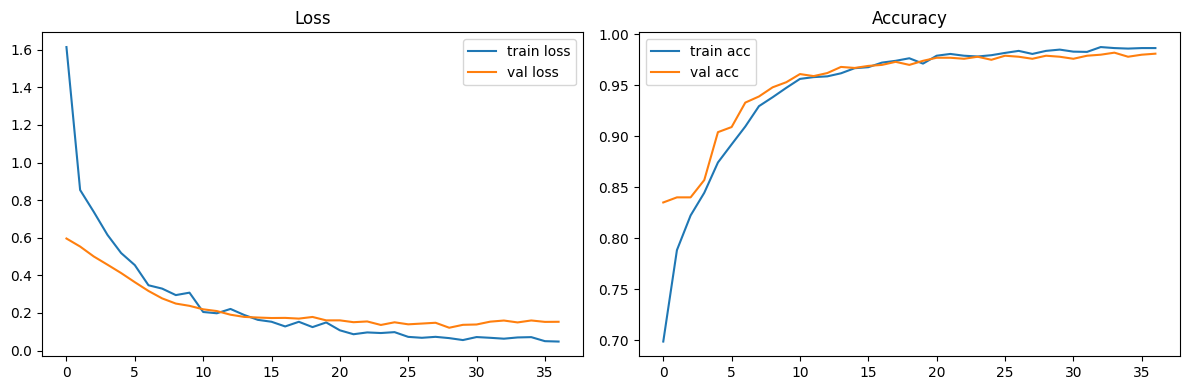

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

=== Classification Report (validacion) ===
                    precision    recall  f1-score   support

    Astro_Positivo       0.99      0.99      0.99       200
Microglia_Positivo       0.97      0.94      0.95       200
   Neuron_Positivo       0.98      1.00      0.99       200
    Oligo_Positivo       0.99      1.00      1.00       200
    Plexo_Positivo       0.96      0.97      0.96       200

          accuracy                           0.98      1000
         macro avg       0.98      0.98      0.98      1000
      weighted avg       0.98      0.98      0.98      1000



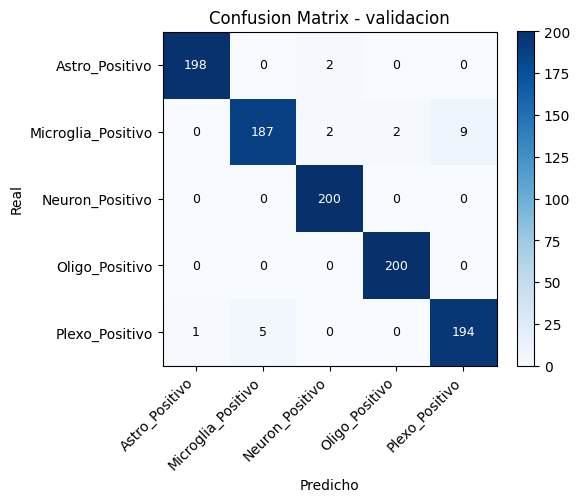

In [17]:
# -- Diagnostico post-entrenamiento ------------------------------------------
# Esta celda evalua si el modelo esta bien calibrado ANTES de pasar al tejido.
# Si la confusion matrix ya muestra sesgo a una clase aqui, el problema es de
# los datos de entrenamiento, no de predict_BTS.

import matplotlib.pyplot as plt

# Curva de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cell_model._history["loss"],     label="train loss")
axes[0].plot(cell_model._history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(cell_model._history["accuracy"],     label="train acc")
axes[1].plot(cell_model._history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

# Classification report y confusion matrix sobre validacion
logits_val = cell_model.model.predict(cell_model._X_val_pca)
y_pred_val = np.argmax(logits_val, axis=1)

print("\n=== Classification Report (validacion) ===")
print(classification_report(cell_model._y_val, y_pred_val, target_names=cell_model.classes_))

cm = confusion_matrix(cell_model._y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cell_model.classes_))); ax.set_xticklabels(cell_model.classes_, rotation=45, ha="right")
ax.set_yticks(range(len(cell_model.classes_))); ax.set_yticklabels(cell_model.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Confusion Matrix - validacion")
plt.tight_layout(); plt.show()


Back-up code (referencia antigua, ya no se usa)

https://docs.scipy.org/doc/scipy/tutorial/sparse.html